##### How can user review/feedback be effectively grouped to identify key areas for app improvement? / Can we Identify common technical issues and feature request based on user reviews to improve the application user experience?

In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [128]:
df = pd.read_csv('gcash-2020-formatted.csv')

In [129]:
df.head()

,Unnamed: 0.1,Unnamed: 0,review_text,review_rating,review_datetime_utc,review_likes,review_text_formatted
0,57770,57770,Please fix your app bug. It has been to weeks ...,2,2020-01-01T00:04:48.000Z,1,"['please', 'fix', 'application', 'bug', 'week'..."
1,57771,57771,I always wanted to cash in for me to use it on...,1,2020-01-01T00:45:51.000Z,0,"['always', 'want', 'cash', 'use', 'billing', '..."
2,57774,57774,Pahelp nmn po dq maaus yung gcash mpin q dhil ...,1,2020-01-01T02:09:35.000Z,0,"['pahelp', 'po', 'dq', 'maaus', 'gcash', 'mpin..."
3,57776,57776,SINCE NOVEMBER UNTIL NOW I CANNOT CASH IN. BEE...,1,2020-01-01T02:47:23.000Z,0,"['since', 'November', 'negativelabel', 'cash',..."
4,57781,57781,Make me disappointed this app when i try to op...,1,2020-01-01T03:51:08.000Z,0,"['make', 'disappointed', 'application', 'try',..."


# Data Pre-Processing

In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33249 entries, 0 to 33248
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Unnamed: 0.1           33249 non-null  int64 
 1   Unnamed: 0             33249 non-null  int64 
 2   review_text            33249 non-null  object
 3   review_rating          33249 non-null  int64 
 4   review_datetime_utc    33249 non-null  object
 5   review_likes           33249 non-null  int64 
 6   review_text_formatted  33249 non-null  object
dtypes: int64(4), object(3)
memory usage: 1.8+ MB


In [131]:
print(df.isna().sum())

Unnamed: 0.1             0
Unnamed: 0               0
review_text              0
review_rating            0
review_datetime_utc      0
review_likes             0
review_text_formatted    0
dtype: int64


In [132]:
print(df['review_rating'].value_counts())

review_rating
1    13107
5    11401
3     3200
2     2806
4     2735
Name: count, dtype: int64


In [133]:
df.drop(columns=['Unnamed: 0.1', 'Unnamed: 0','review_datetime_utc'], inplace=True)
df.dropna(inplace=True)

In [134]:
df.head()

,review_text,review_rating,review_likes,review_text_formatted
0,Please fix your app bug. It has been to weeks ...,2,1,"['please', 'fix', 'application', 'bug', 'week'..."
1,I always wanted to cash in for me to use it on...,1,0,"['always', 'want', 'cash', 'use', 'billing', '..."
2,Pahelp nmn po dq maaus yung gcash mpin q dhil ...,1,0,"['pahelp', 'po', 'dq', 'maaus', 'gcash', 'mpin..."
3,SINCE NOVEMBER UNTIL NOW I CANNOT CASH IN. BEE...,1,0,"['since', 'November', 'negativelabel', 'cash',..."
4,Make me disappointed this app when i try to op...,1,0,"['make', 'disappointed', 'application', 'try',..."


In [135]:
import re

df['review_text_formatted'] = df['review_text_formatted'].apply(
    lambda x: re.sub(r"[\[\]']", '', x)  # Removes [, ], and ' characters
)

df['review_text_formatted'] = df['review_text_formatted'].apply(
    lambda x: x.replace(',', '') if isinstance(x, str) else x
)

In [136]:
df.head()

,review_text,review_rating,review_likes,review_text_formatted
0,Please fix your app bug. It has been to weeks ...,2,1,please fix application bug week still transfer...
1,I always wanted to cash in for me to use it on...,1,0,always want cash use billing load everytime go...
2,Pahelp nmn po dq maaus yung gcash mpin q dhil ...,1,0,pahelp po dq maaus gcash mpin dhil pinakialamn...
3,SINCE NOVEMBER UNTIL NOW I CANNOT CASH IN. BEE...,1,0,since November negativelabel cash receive msg ...
4,Make me disappointed this app when i try to op...,1,0,make disappointed application try open gcash a...


In [137]:
print(df.duplicated(subset=['review_text_formatted']).sum())
df = df.drop_duplicates(subset=['review_text_formatted'])

1992


# Exploratory Data Analysis

Top 20 Most Frequent Words in Reviews

In [138]:
word_list = df['review_text_formatted'].str.split().explode()  # Flatten tokenized words
word_freq = Counter(word_list)

# View top 20 words
print(word_freq.most_common(20))

[('negativelabel', 20698), ('application', 11934), ('gcash', 8450), ('use', 6279), ('update', 4774), ('money', 4469), ('account', 3906), ('load', 3536), ('verify', 3518), ('good', 3331), ('id', 3064), ('please', 2965), ('time', 2898), ('need', 2857), ('always', 2643), ('transaction', 2474), ('cash', 2443), ('easy', 2397), ('send', 2271), ('pay', 2269)]


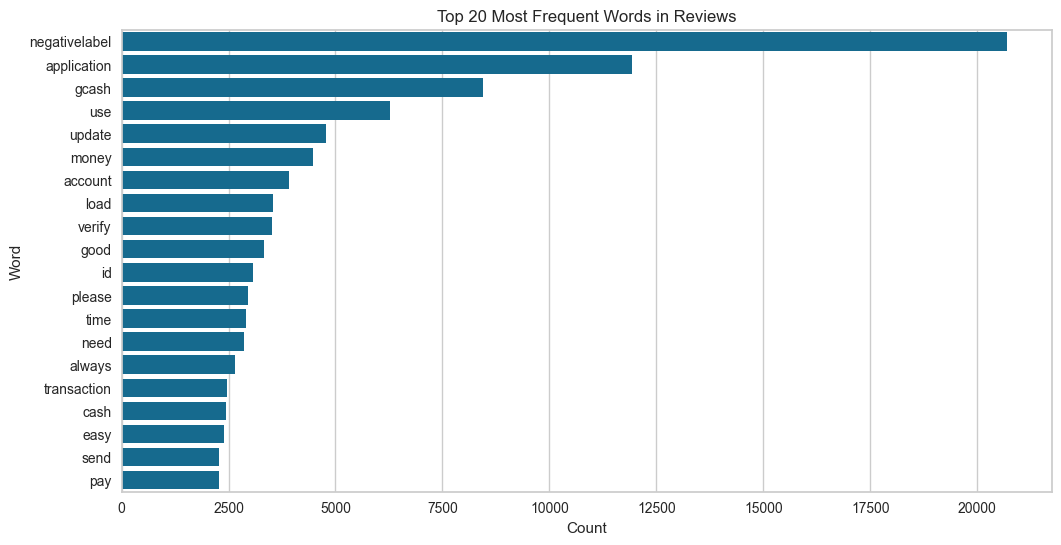

In [139]:
top_words = pd.DataFrame(word_freq.most_common(20), columns=['Word', 'Count'])

plt.figure(figsize=(12, 6))
sns.barplot(x='Count', y='Word', data=top_words)
plt.title("Top 20 Most Frequent Words in Reviews")
plt.show()


Distribution of Review Lengths

In [140]:
df['text_length'] = df['review_text'].apply(lambda x: len(x.split()))
print(df['text_length'].describe())  # Summary stats

count    31257.000000
mean        19.623988
std         18.301977
min          1.000000
25%          7.000000
50%         13.000000
75%         25.000000
max        122.000000
Name: text_length, dtype: float64


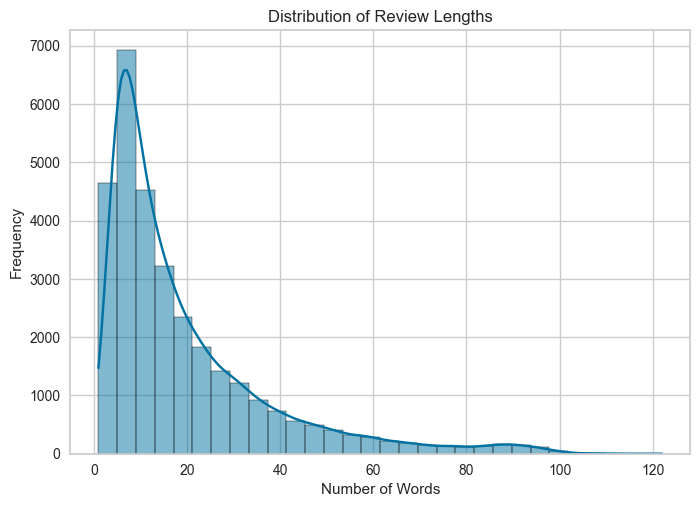

In [141]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['text_length'], bins=30, kde=True)
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.title("Distribution of Review Lengths")
plt.show()

df.drop(columns=['text_length'], inplace=True)

# Feature Representation

In [142]:
df['review_text_formatted'] = df['review_text_formatted'].str.lower()

In [143]:
df.head()

,review_text,review_rating,review_likes,review_text_formatted
0,Please fix your app bug. It has been to weeks ...,2,1,please fix application bug week still transfer...
1,I always wanted to cash in for me to use it on...,1,0,always want cash use billing load everytime go...
2,Pahelp nmn po dq maaus yung gcash mpin q dhil ...,1,0,pahelp po dq maaus gcash mpin dhil pinakialamn...
3,SINCE NOVEMBER UNTIL NOW I CANNOT CASH IN. BEE...,1,0,since november negativelabel cash receive msg ...
4,Make me disappointed this app when i try to op...,1,0,make disappointed application try open gcash a...


In [144]:
vectorizer = TfidfVectorizer(sublinear_tf=True, min_df=5, max_df=0.95)
X = vectorizer.fit_transform(df['review_text_formatted']).toarray()

In [145]:
df_tfidf = pd.DataFrame(X, columns=vectorizer.get_feature_names_out())
print(df_tfidf)

       100x  10x  15th  1hour  1st  1star  1week  24hr  2day  2nd  ...  you  \
0       0.0  0.0   0.0    0.0  0.0    0.0    0.0   0.0   0.0  0.0  ...  0.0   
1       0.0  0.0   0.0    0.0  0.0    0.0    0.0   0.0   0.0  0.0  ...  0.0   
2       0.0  0.0   0.0    0.0  0.0    0.0    0.0   0.0   0.0  0.0  ...  0.0   
3       0.0  0.0   0.0    0.0  0.0    0.0    0.0   0.0   0.0  0.0  ...  0.0   
4       0.0  0.0   0.0    0.0  0.0    0.0    0.0   0.0   0.0  0.0  ...  0.0   
...     ...  ...   ...    ...  ...    ...    ...   ...   ...  ...  ...  ...   
31252   0.0  0.0   0.0    0.0  0.0    0.0    0.0   0.0   0.0  0.0  ...  0.0   
31253   0.0  0.0   0.0    0.0  0.0    0.0    0.0   0.0   0.0  0.0  ...  0.0   
31254   0.0  0.0   0.0    0.0  0.0    0.0    0.0   0.0   0.0  0.0  ...  0.0   
31255   0.0  0.0   0.0    0.0  0.0    0.0    0.0   0.0   0.0  0.0  ...  0.0   
31256   0.0  0.0   0.0    0.0  0.0    0.0    0.0   0.0   0.0  0.0  ...  0.0   

       young  your  youtube  ypu  yun  zero  zolo  

In [146]:
print(f"Original DataFrame shape: {df.shape}")
print(f"TF-IDF matrix shape: {X.shape}")

Original DataFrame shape: (31257, 4)
TF-IDF matrix shape: (31257, 3198)


In [147]:
df.head()

,review_text,review_rating,review_likes,review_text_formatted
0,Please fix your app bug. It has been to weeks ...,2,1,please fix application bug week still transfer...
1,I always wanted to cash in for me to use it on...,1,0,always want cash use billing load everytime go...
2,Pahelp nmn po dq maaus yung gcash mpin q dhil ...,1,0,pahelp po dq maaus gcash mpin dhil pinakialamn...
3,SINCE NOVEMBER UNTIL NOW I CANNOT CASH IN. BEE...,1,0,since november negativelabel cash receive msg ...
4,Make me disappointed this app when i try to op...,1,0,make disappointed application try open gcash a...


In [148]:
df_copy = df.copy()

In [149]:
df = pd.concat([df, df_tfidf], axis=1)

In [150]:
df.head()

,review_text,review_rating,review_likes,review_text_formatted,100x,10x,15th,1hour,1st,1star,...,you,young,your,youtube,ypu,yun,zero,zolo,zoloz,zoom
0,Please fix your app bug. It has been to weeks ...,2.0,1.0,please fix application bug week still transfer...,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,I always wanted to cash in for me to use it on...,1.0,0.0,always want cash use billing load everytime go...,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Pahelp nmn po dq maaus yung gcash mpin q dhil ...,1.0,0.0,pahelp po dq maaus gcash mpin dhil pinakialamn...,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,SINCE NOVEMBER UNTIL NOW I CANNOT CASH IN. BEE...,1.0,0.0,since november negativelabel cash receive msg ...,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Make me disappointed this app when i try to op...,1.0,0.0,make disappointed application try open gcash a...,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Dimentionality Reduction

In [151]:
df.drop(columns=['review_text_formatted', 'review_likes', 'review_rating', 'review_text'], inplace=True)

In [152]:
print(df.isna().sum())

100x     1811
10x      1811
15th     1811
1hour    1811
1st      1811
         ... 
yun      1811
zero     1811
zolo     1811
zoloz    1811
zoom     1811
Length: 3198, dtype: int64


In [153]:
df.dropna(inplace=True)
print(df.isna().sum())

100x     0
10x      0
15th     0
1hour    0
1st      0
        ..
yun      0
zero     0
zolo     0
zoloz    0
zoom     0
Length: 3198, dtype: int64


In [154]:
df.head()

,100x,10x,15th,1hour,1st,1star,1week,24hr,2day,2nd,...,you,young,your,youtube,ypu,yun,zero,zolo,zoloz,zoom
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [155]:
from sklearn.decomposition import TruncatedSVD

components = 100

svd = TruncatedSVD(n_components=components, random_state=42)  # Try 300 first
X_svd = svd.fit_transform(df)  # X is your TF-IDF matrix

print("Original shape:", df.shape)
print("Reduced shape:", X_svd.shape)

Original shape: (31257, 3198)
Reduced shape: (31257, 100)


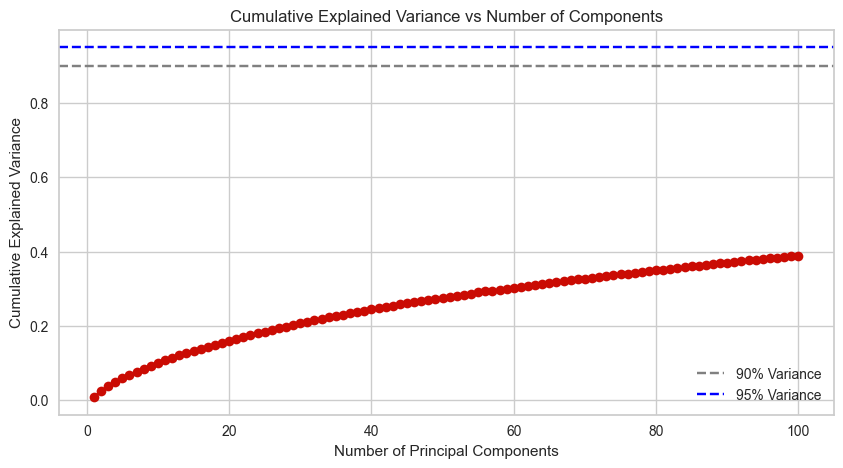

In [156]:
explained_variance = svd.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(10, 5))
plt.plot(range(1, components + 1), cumulative_variance, marker='o', linestyle='-', color='r')

# Add Threshold Lines
plt.axhline(y=0.90, color='gray', linestyle='--', label='90% Variance')
plt.axhline(y=0.95, color='blue', linestyle='--', label='95% Variance')

plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance vs Number of Components')
plt.legend()
plt.grid(True)

plt.show()

In [157]:
import umap

# umap_reducer = umap.UMAP(n_components=2, random_state=42)
umap_reducer = umap.UMAP(n_components=2, n_neighbors=100, min_dist=0.05, random_state=42)
X_umap = umap_reducer.fit_transform(X_svd)

c:\Users\Neil\miniconda3\envs\COM222\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


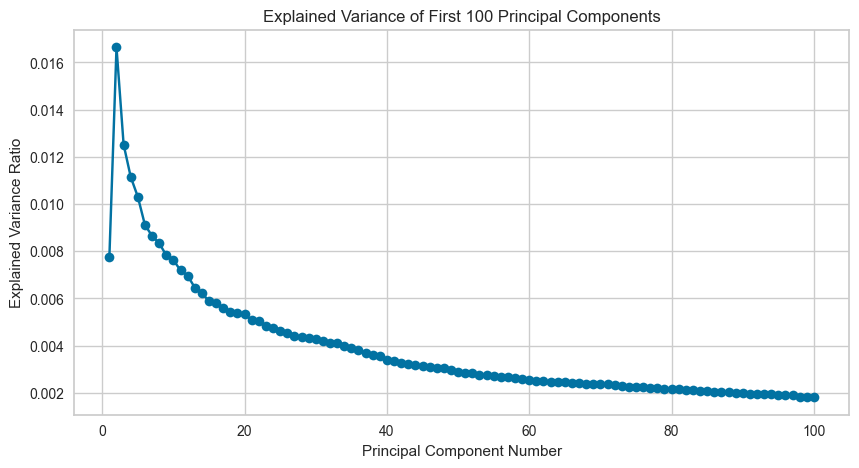

In [158]:
plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, components + 1), explained_variance, marker='o', linestyle='-', color='b')

plt.xlabel('Principal Component Number')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance of First 100 Principal Components')
plt.grid(True)

plt.show()

# Kmeans Clustering

Elbow Method to determine the number of clusters to be formed:


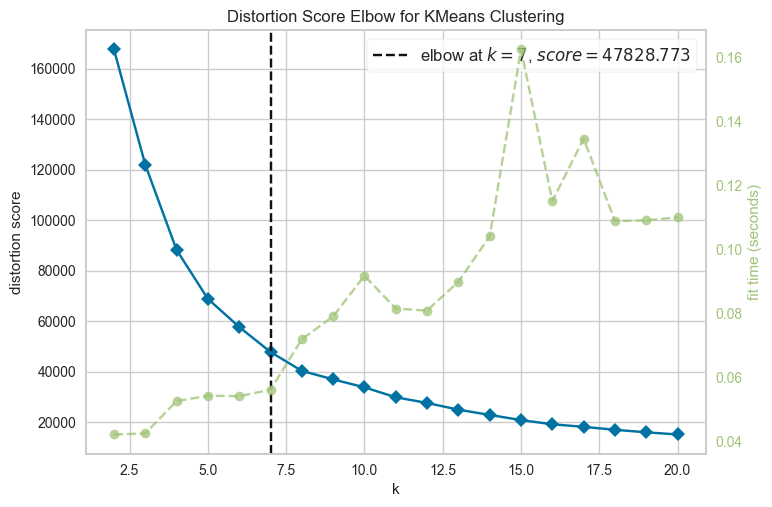

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [159]:
from yellowbrick.cluster import KElbowVisualizer

print('Elbow Method to determine the number of clusters to be formed:')
Elbow_M = KElbowVisualizer(KMeans(max_iter=100, n_init='auto', init='k-means++', random_state=42), k=20)
Elbow_M.fit(X_umap)
Elbow_M.show()

In [160]:
num_clusters = Elbow_M.elbow_value_
kmeans = KMeans(n_clusters=num_clusters, random_state=42)

df['cluster'] = kmeans.fit_predict(X_umap)
kmeans_labels = kmeans.labels_

df_copy['cluster'] = df['cluster']

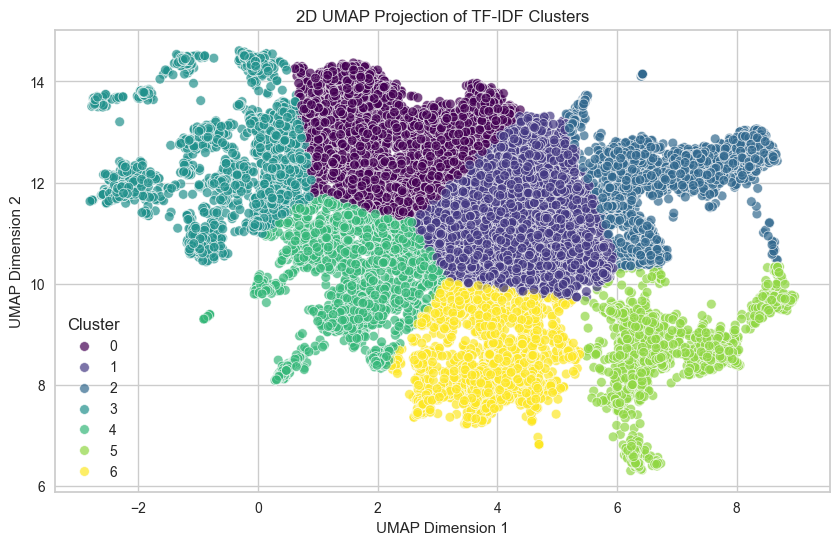

In [161]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=df['cluster'], palette="viridis", alpha=0.7)
plt.title("2D UMAP Projection of TF-IDF Clusters")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend(title="Cluster")
plt.show()

In [162]:
df_copy.drop(columns=['review_text_formatted', 'review_likes', 'review_rating'], inplace=True)
df_copy.dropna(inplace=True)
df_copy.to_csv("sentence_2020.csv", index=False)
df_copy

,review_text,cluster
0,Please fix your app bug. It has been to weeks ...,0.0
1,I always wanted to cash in for me to use it on...,6.0
2,Pahelp nmn po dq maaus yung gcash mpin q dhil ...,5.0
3,SINCE NOVEMBER UNTIL NOW I CANNOT CASH IN. BEE...,0.0
4,Make me disappointed this app when i try to op...,6.0
...,...,...
31252,Remove the processing fees and other charges. ...,6.0
31253,There should be a maximum amount for the 15php...,4.0
31254,It's hard to sign in pls fix this.,6.0
31255,great we found gcash apps...,1.0



Cluster 0 - TF-IDF Scores:
money: 0.0755
pay: 0.0722
bill: 0.0701
cash: 0.0594
easy: 0.0526
negativelabel: 0.0484
gcash: 0.0466
transfer: 0.0443
application: 0.0414
transaction: 0.0408
payment: 0.0395
bank: 0.0372
use: 0.0361
send: 0.0338
convenient: 0.0329
good: 0.0310
load: 0.0275
free: 0.0275
hassle: 0.0244
online: 0.0243


C:\Users\Neil\AppData\Local\Temp\ipykernel_17544\329755581.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=scores, y=words, palette="viridis")


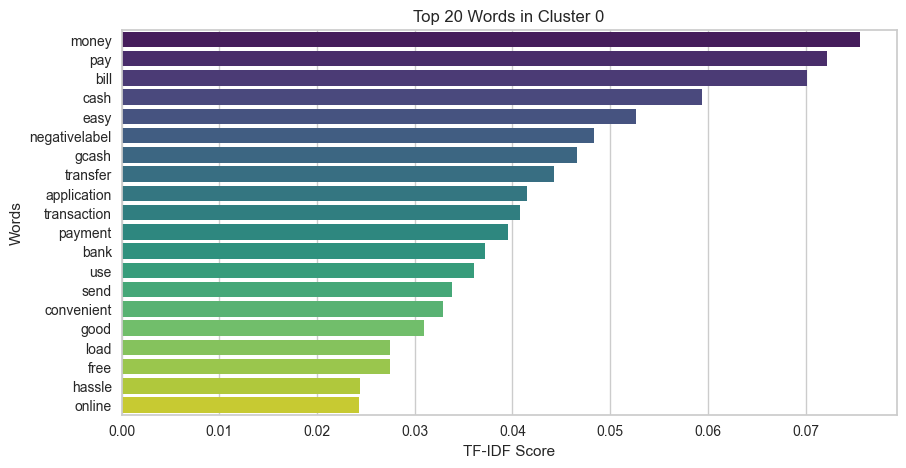


Cluster 1 - TF-IDF Scores:
negativelabel: 0.0860
application: 0.0447
gcash: 0.0430
account: 0.0340
use: 0.0332
service: 0.0308
please: 0.0298
fix: 0.0289
login: 0.0279
get: 0.0242
say: 0.0239
even: 0.0234
error: 0.0226
try: 0.0212
customer: 0.0209
mpin: 0.0197
money: 0.0194
bad: 0.0194
still: 0.0191
time: 0.0184


C:\Users\Neil\AppData\Local\Temp\ipykernel_17544\329755581.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=scores, y=words, palette="viridis")


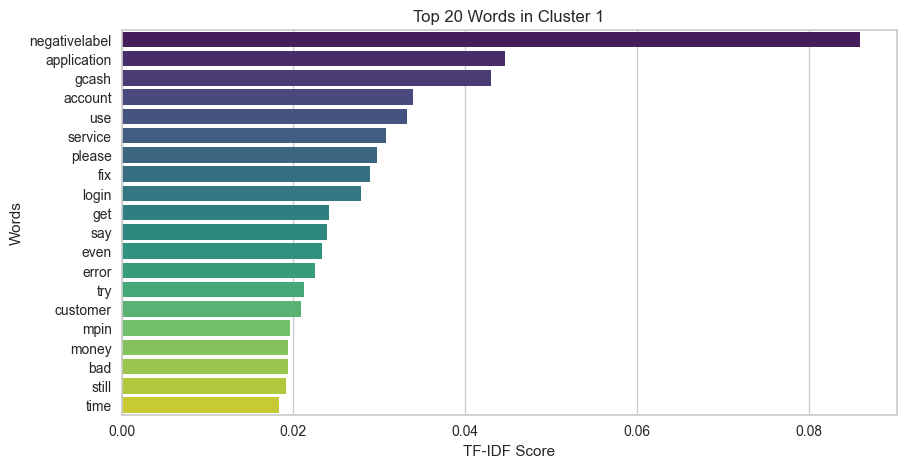


Cluster 2 - TF-IDF Scores:
verify: 0.1432
id: 0.1371
negativelabel: 0.1099
student: 0.0864
account: 0.0658
code: 0.0604
fully: 0.0594
verification: 0.0561
please: 0.0416
get: 0.0391
send: 0.0314
email: 0.0310
try: 0.0290
use: 0.0280
option: 0.0258
valid: 0.0254
take: 0.0243
receive: 0.0238
application: 0.0237
fix: 0.0234


C:\Users\Neil\AppData\Local\Temp\ipykernel_17544\329755581.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=scores, y=words, palette="viridis")


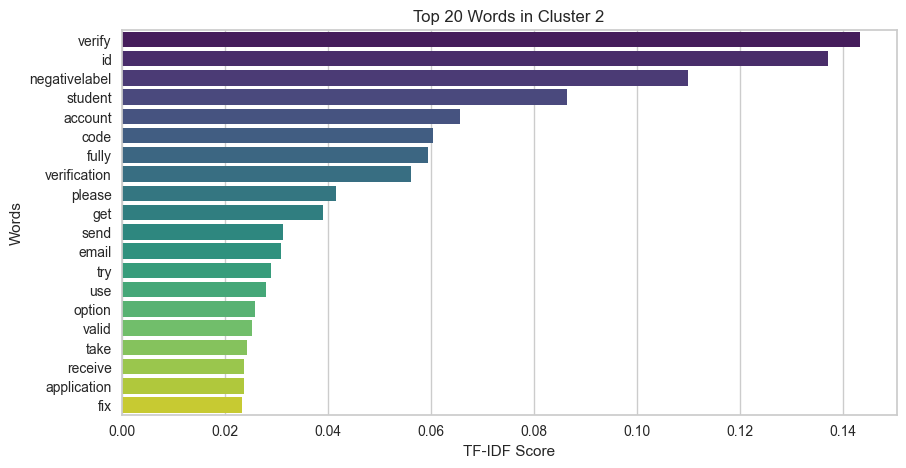


Cluster 3 - TF-IDF Scores:
application: 0.1049
easy: 0.0941
nice: 0.0916
use: 0.0661
great: 0.0637
love: 0.0601
useful: 0.0573
fast: 0.0489
gcash: 0.0483
helpful: 0.0451
thank: 0.0441
convenient: 0.0427
good: 0.0398
transaction: 0.0385
thanks: 0.0345
super: 0.0283
verry: 0.0232
money: 0.0216
usefull: 0.0207
make: 0.0191


C:\Users\Neil\AppData\Local\Temp\ipykernel_17544\329755581.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=scores, y=words, palette="viridis")


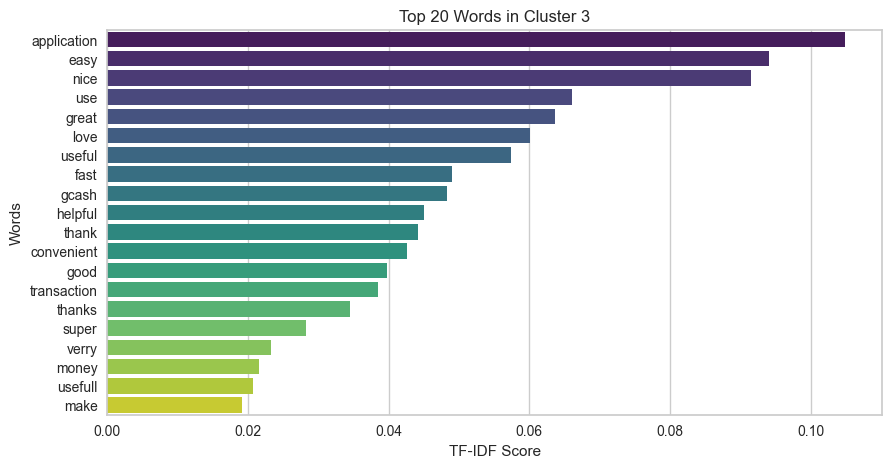


Cluster 4 - TF-IDF Scores:
good: 0.1004
load: 0.0988
application: 0.0703
buy: 0.0595
negativelabel: 0.0582
gcash: 0.0384
use: 0.0381
rebate: 0.0366
star: 0.0353
sometimes: 0.0303
like: 0.0293
give: 0.0284
time: 0.0269
help: 0.0203
experience: 0.0197
really: 0.0196
user: 0.0192
lot: 0.0159
please: 0.0154
need: 0.0144


C:\Users\Neil\AppData\Local\Temp\ipykernel_17544\329755581.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=scores, y=words, palette="viridis")


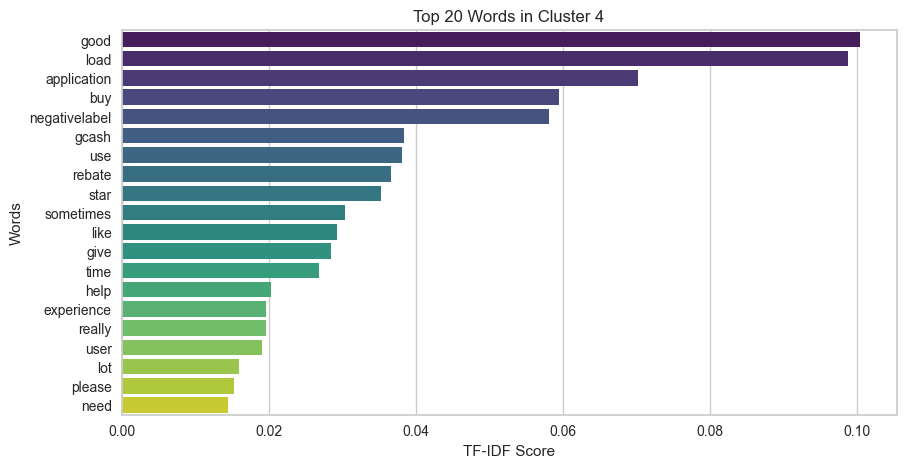


Cluster 5 - TF-IDF Scores:
po: 0.0716
ninyo: 0.0650
lang: 0.0619
mag: 0.0578
ok: 0.0544
palagi: 0.0536
negativelabel: 0.0397
sana: 0.0395
nag: 0.0387
update: 0.0372
gcash: 0.0370
pag: 0.0344
application: 0.0224
kayo: 0.0221
tapos: 0.0197
ung: 0.0197
ba: 0.0186
kasi: 0.0182
money: 0.0178
matagal: 0.0172


C:\Users\Neil\AppData\Local\Temp\ipykernel_17544\329755581.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=scores, y=words, palette="viridis")


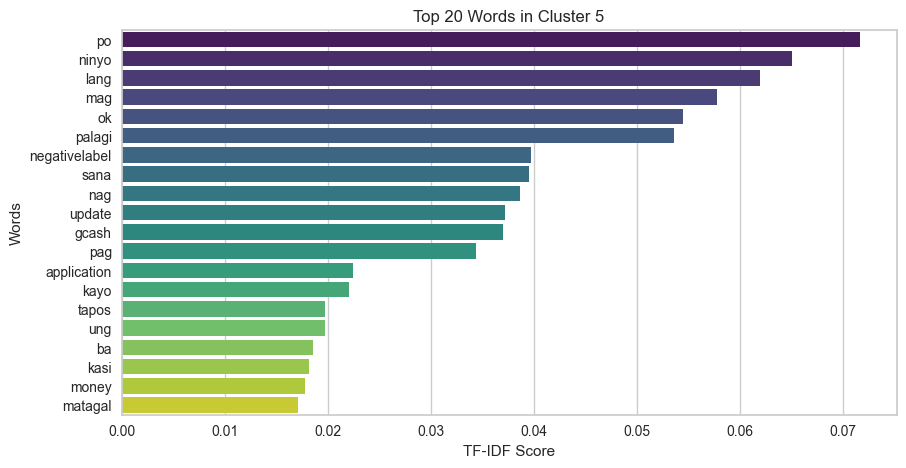


Cluster 6 - TF-IDF Scores:
update: 0.1567
always: 0.0914
negativelabel: 0.0898
application: 0.0735
open: 0.0691
need: 0.0647
updating: 0.0434
use: 0.0352
work: 0.0342
gcash: 0.0340
download: 0.0328
time: 0.0324
slow: 0.0252
every: 0.0216
please: 0.0196
everytime: 0.0162
keep: 0.0155
install: 0.0154
new: 0.0153
account: 0.0151


C:\Users\Neil\AppData\Local\Temp\ipykernel_17544\329755581.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=scores, y=words, palette="viridis")


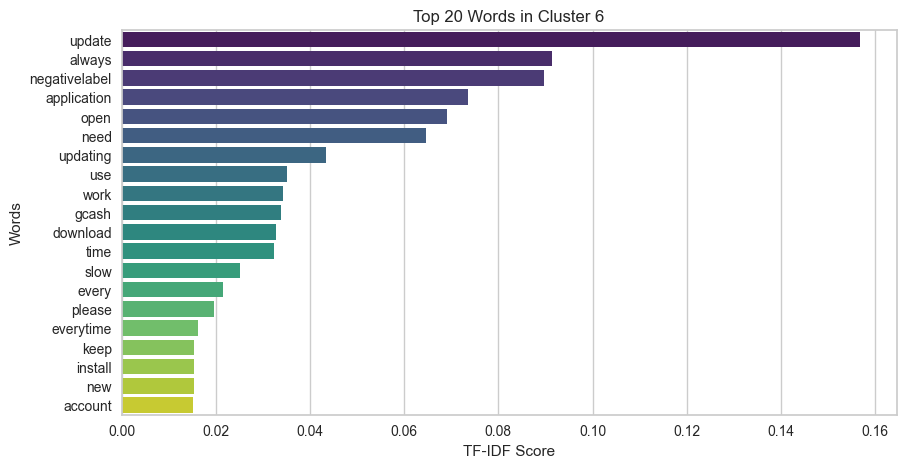

In [163]:
terms = vectorizer.get_feature_names_out()

# Inverse transform cluster centers back to TF-IDF space
# Compute cluster centers in the original X_svd space
cluster_centers_svd = np.array([X_svd[kmeans_labels == i].mean(axis=0) for i in range(num_clusters)])
approx_tfidf = svd.inverse_transform(cluster_centers_svd)


def plot_top_words(cluster_index, top_n=10):
    if cluster_index >= num_clusters:
        return None
    
    term_frequencies = approx_tfidf[cluster_index]
    
    # Get top N words in this cluster
    sorted_indices = np.argsort(term_frequencies)[::-1][:top_n]
    words = [terms[i] for i in sorted_indices]
    scores = [term_frequencies[i] for i in sorted_indices]

    # Print scores array
    print(f"\nCluster {cluster_index} - TF-IDF Scores:")
    for word, score in zip(words, scores):
        print(f"{word}: {score:.4f}")  # Format to 4 decimal places

    # Plot bar chart
    plt.figure(figsize=(10, 5))
    sns.barplot(x=scores, y=words, palette="viridis")
    plt.xlabel("TF-IDF Score")
    plt.ylabel("Words")
    plt.title(f"Top {top_n} Words in Cluster {cluster_index}")
    plt.show()

# Print & Plot words for each cluster
for i in range(num_clusters):
    plot_top_words(i, top_n=20)


In [164]:
# # Extract feature names (words)
# terms = vectorizer.get_feature_names_out()

# # Ensure df_tfidf is a DataFrame and matches df's shape
# df_tfidf = pd.DataFrame(X, columns=terms)

# # Merge with cluster labels from df (ensuring alignment)
# df_tfidf['cluster'] = df['cluster'].values

# # Compute total TF-IDF scores per word in each cluster
# cluster_word_counts = df_tfidf.groupby('cluster').sum()  # Sum TF-IDF values per cluster

# def plot_top_words(cluster_index, top_n=10):
#     if cluster_index >= num_clusters:
#         return None

#     # Get TF-IDF scores for this cluster
#     term_frequencies = cluster_word_counts.iloc[cluster_index]

#     # Get top N words based on TF-IDF score
#     sorted_indices = term_frequencies.argsort()[::-1][:top_n]
#     words = [terms[i] for i in sorted_indices]
#     scores = [term_frequencies.iloc[i] for i in sorted_indices]
    
#     # Get actual word occurrences from the original dataset
#     counts = df_tfidf[words].sum().values  # Get word counts for selected top words

#     # Plot bar chart
#     plt.figure(figsize=(10, 5))
#     ax = sns.barplot(x=scores, y=words, palette="viridis")

#     # Add text labels for total word counts
#     for i, count in enumerate(counts):
#         ax.text(scores[i], i, f" {int(count)}", va='center', fontsize=10, color='black')

#     plt.xlabel("TF-IDF Score (Summed per Cluster)")
#     plt.ylabel("Words")
#     plt.title(f"Top {top_n} Words in Cluster {cluster_index}")
#     plt.show()

# # Plot words for each cluster
# for i in range(num_clusters):
#     plot_top_words(i, top_n=10)  # Adjust top_n if needed


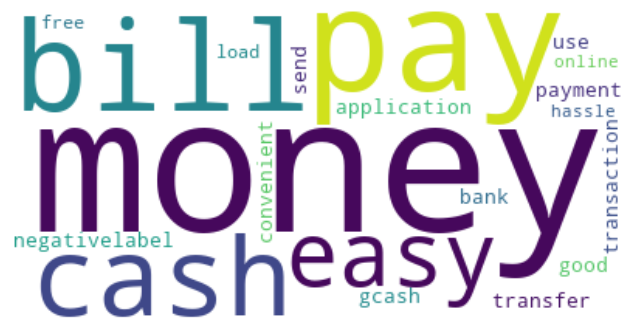

{'money': np.float64(0.0755160349170102), 'pay': np.float64(0.0721639692219115), 'bill': np.float64(0.0700860765182385), 'cash': np.float64(0.05942943977919417), 'easy': np.float64(0.052626180125381256), 'negativelabel': np.float64(0.0483588443979409), 'gcash': np.float64(0.0465538635724844), 'transfer': np.float64(0.044296595302015976), 'application': np.float64(0.041433806184010005), 'transaction': np.float64(0.04080177690037805), 'payment': np.float64(0.03954124011470582), 'bank': np.float64(0.03718220994400948), 'use': np.float64(0.036083470882828164), 'send': np.float64(0.033839384617604475), 'convenient': np.float64(0.032862890555107584), 'good': np.float64(0.030974057124138976), 'load': np.float64(0.027499756369522448), 'free': np.float64(0.027473699836448734), 'hassle': np.float64(0.024432645191168535), 'online': np.float64(0.024277512249638443)}


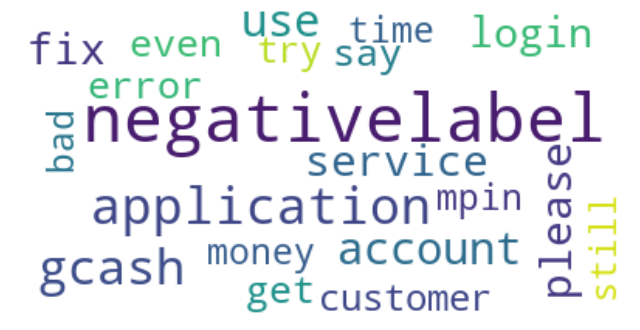

{'negativelabel': np.float64(0.08595266933052419), 'application': np.float64(0.04465911057079714), 'gcash': np.float64(0.04299335880205633), 'account': np.float64(0.03398651330901634), 'use': np.float64(0.033219426940351085), 'service': np.float64(0.030795428613946477), 'please': np.float64(0.02977363214568902), 'fix': np.float64(0.028932600538447942), 'login': np.float64(0.02785938638824473), 'get': np.float64(0.024185890308572287), 'say': np.float64(0.023890688617680907), 'even': np.float64(0.023392975264465817), 'error': np.float64(0.022586148417841716), 'try': np.float64(0.021246092173332433), 'customer': np.float64(0.020942774206344803), 'mpin': np.float64(0.019675428881997848), 'money': np.float64(0.01943886051723298), 'bad': np.float64(0.019366793983006204), 'still': np.float64(0.019110208431330763), 'time': np.float64(0.01838185309553377)}


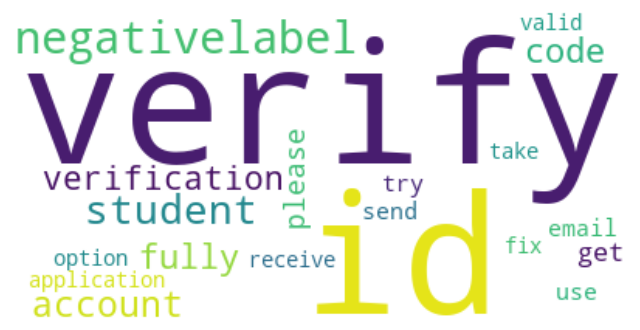

{'verify': np.float64(0.1432334017587289), 'id': np.float64(0.1371290611859318), 'negativelabel': np.float64(0.10988556280209197), 'student': np.float64(0.08642212003776445), 'account': np.float64(0.06576063337140348), 'code': np.float64(0.060439981690573366), 'fully': np.float64(0.05938750390039008), 'verification': np.float64(0.05611067866649212), 'please': np.float64(0.04160346062651123), 'get': np.float64(0.03907731621114445), 'send': np.float64(0.03142335576375513), 'email': np.float64(0.03102916350490808), 'try': np.float64(0.029013587916377998), 'use': np.float64(0.02797612238538164), 'option': np.float64(0.02580651757325186), 'valid': np.float64(0.025398835448406373), 'take': np.float64(0.024304506123422654), 'receive': np.float64(0.023795290165400034), 'application': np.float64(0.02371066023078105), 'fix': np.float64(0.023426773725998284)}


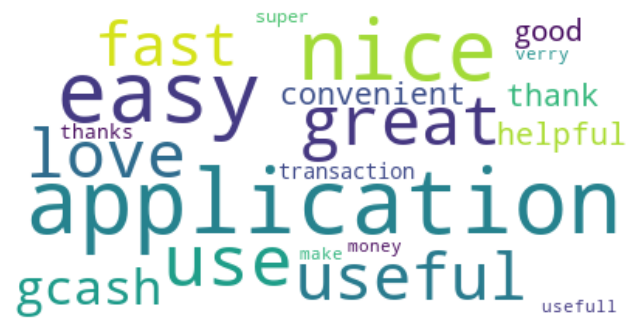

{'application': np.float64(0.10492593744392789), 'easy': np.float64(0.09411058278617679), 'nice': np.float64(0.09157008264224444), 'use': np.float64(0.06605613452123603), 'great': np.float64(0.06367994478176227), 'love': np.float64(0.06009612912383988), 'useful': np.float64(0.057338801887461786), 'fast': np.float64(0.04894434618592559), 'gcash': np.float64(0.04833046379224852), 'helpful': np.float64(0.04505628101177972), 'thank': np.float64(0.04410336946359586), 'convenient': np.float64(0.042663831342155296), 'good': np.float64(0.039801121478381676), 'transaction': np.float64(0.038534618977762065), 'thanks': np.float64(0.034456627097745406), 'super': np.float64(0.028305298053163366), 'verry': np.float64(0.02322152283101445), 'money': np.float64(0.02162595752169952), 'usefull': np.float64(0.02072152849216369), 'make': np.float64(0.01910400469760784)}


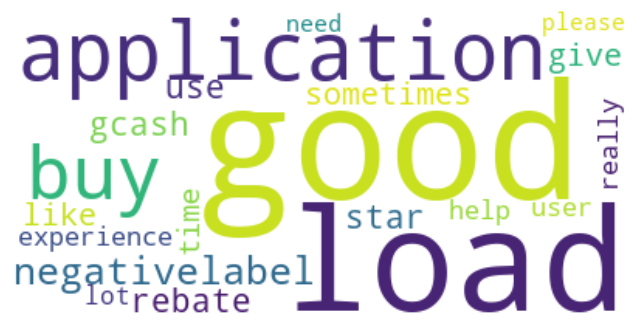

{'good': np.float64(0.10035684768571948), 'load': np.float64(0.09878144808712236), 'application': np.float64(0.07025994688566128), 'buy': np.float64(0.05946592198822021), 'negativelabel': np.float64(0.058175266083330075), 'gcash': np.float64(0.03835525229767475), 'use': np.float64(0.03808907339087465), 'rebate': np.float64(0.03659367110214781), 'star': np.float64(0.035279413378998405), 'sometimes': np.float64(0.030321841477424463), 'like': np.float64(0.029291830462636607), 'give': np.float64(0.028430658552756474), 'time': np.float64(0.026915606514257104), 'help': np.float64(0.02028735960733712), 'experience': np.float64(0.019668629791442335), 'really': np.float64(0.01961409981747028), 'user': np.float64(0.019154663519651047), 'lot': np.float64(0.01594812525352913), 'please': np.float64(0.015358992553506425), 'need': np.float64(0.014438158405059819)}


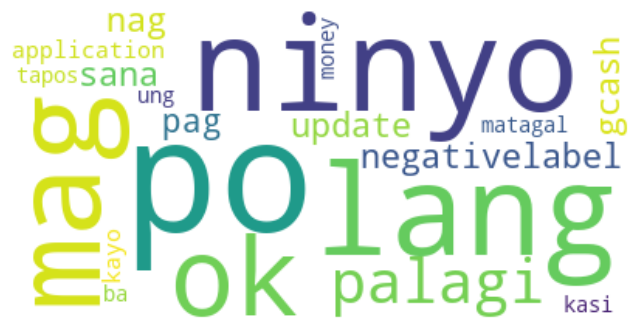

{'po': np.float64(0.07158811898131627), 'ninyo': np.float64(0.0649868659258301), 'lang': np.float64(0.06190228344437742), 'mag': np.float64(0.057761282699796156), 'ok': np.float64(0.05442363003502933), 'palagi': np.float64(0.05356964478146399), 'negativelabel': np.float64(0.03973284945986952), 'sana': np.float64(0.03949033601242498), 'nag': np.float64(0.038681203846435565), 'update': np.float64(0.03723320837049723), 'gcash': np.float64(0.03695373745204595), 'pag': np.float64(0.03440125940104093), 'application': np.float64(0.02241598187314299), 'kayo': np.float64(0.022103992656727866), 'tapos': np.float64(0.019712662627634592), 'ung': np.float64(0.019691592631169003), 'ba': np.float64(0.018561034067996147), 'kasi': np.float64(0.018194075450401827), 'money': np.float64(0.017812829209335714), 'matagal': np.float64(0.01716110331547671)}


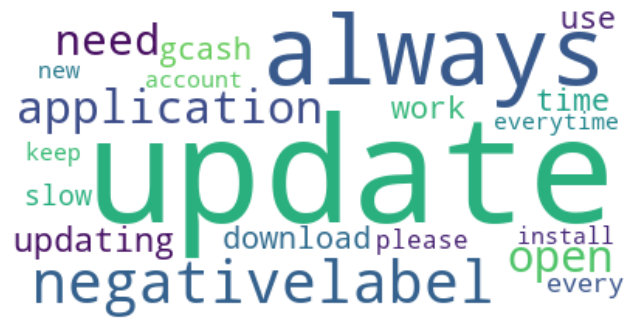

{'update': np.float64(0.1567041099571404), 'always': np.float64(0.09143718273434336), 'negativelabel': np.float64(0.08977871328509643), 'application': np.float64(0.07353913993957689), 'open': np.float64(0.06906548962780099), 'need': np.float64(0.06472247758731424), 'updating': np.float64(0.04338935336830586), 'use': np.float64(0.03521894723278198), 'work': np.float64(0.03418237804748275), 'gcash': np.float64(0.033951724706262024), 'download': np.float64(0.03276530510274389), 'time': np.float64(0.03236966640182161), 'slow': np.float64(0.025192406813878614), 'every': np.float64(0.021571203299934436), 'please': np.float64(0.0195851637539041), 'everytime': np.float64(0.01617295154927448), 'keep': np.float64(0.015481869366027717), 'install': np.float64(0.015430533878860557), 'new': np.float64(0.015293065112735945), 'account': np.float64(0.015107685489280303)}


In [165]:
# Get original feature names (words)
from wordcloud import WordCloud

def frequencies_dict(cluster_index):
    if cluster_index >= num_clusters:
        return None
    
    term_frequencies = approx_tfidf[cluster_index]
    
    # Get top 20 words in this cluster
    sorted_indices = np.argsort(term_frequencies)[::-1][:20]
    frequencies = {terms[i]: term_frequencies[i] for i in sorted_indices}
    
    return frequencies

def makeImage(frequencies):
    wc = WordCloud(background_color="white", max_words=50)
    wc.generate_from_frequencies(frequencies)

    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.show()

for i in range(num_clusters):
    freq = frequencies_dict(i)
    if freq:
        makeImage(freq)
        print(freq)  # Optional: Print words with weights

# def frequencies_dict(cluster_index, top_n=20):
#     """Return a dictionary of top words and their TF-IDF scores for a given cluster."""
#     if cluster_index >= num_clusters:
#         return None

#     # Get term frequencies (TF-IDF sum per word in the cluster)
#     term_frequencies = cluster_word_counts.iloc[cluster_index]

#     # Get top N words based on TF-IDF score
#     sorted_indices = term_frequencies.argsort()[::-1][:top_n]
#     frequencies = {terms[i]: term_frequencies.iloc[i] for i in sorted_indices}

#     return frequencies

# def makeImage(frequencies):
#     """Generate and display a word cloud from word frequencies."""
#     wc = WordCloud(background_color="white", max_words=50)
#     wc.generate_from_frequencies(frequencies)

#     plt.figure(figsize=(8, 6))
#     plt.imshow(wc, interpolation="bilinear")
#     plt.axis("off")
#     plt.show()

# # Generate word clouds for each cluster
# for i in range(num_clusters):
#     freq = frequencies_dict(i, top_n=20)  # Adjust top_n as needed
#     if freq:
#         makeImage(freq)
#         print(freq)  # Optional: Print words with TF-IDF scores


C:\Users\Neil\AppData\Local\Temp\ipykernel_17544\190333237.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=scores, y=words, ax=axes[1], palette="viridis")


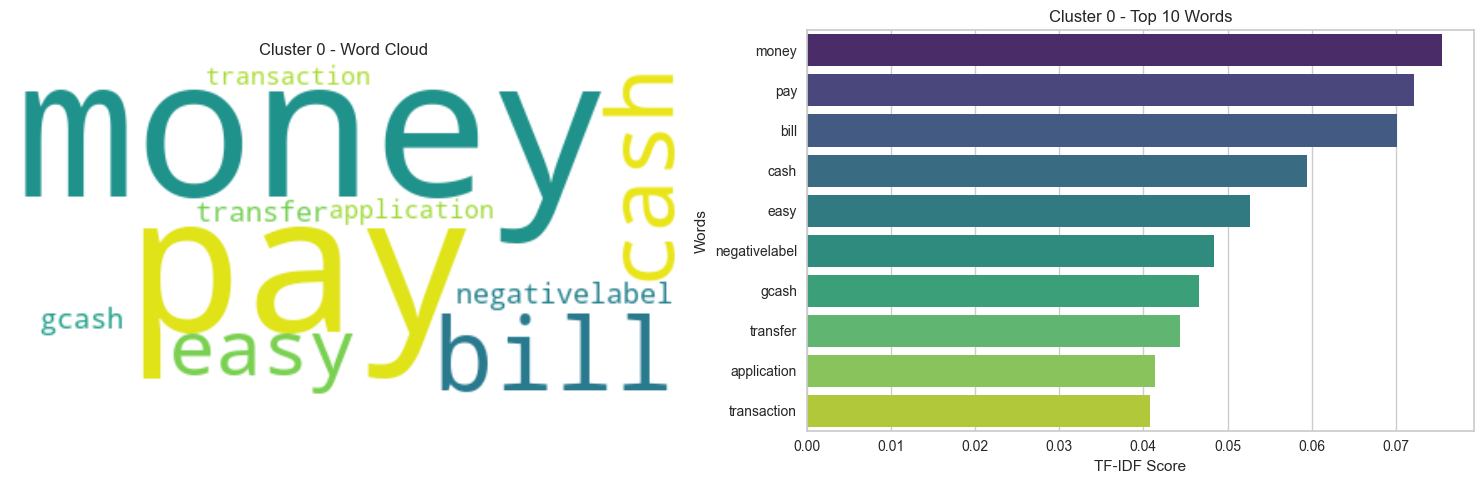

C:\Users\Neil\AppData\Local\Temp\ipykernel_17544\190333237.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=scores, y=words, ax=axes[1], palette="viridis")


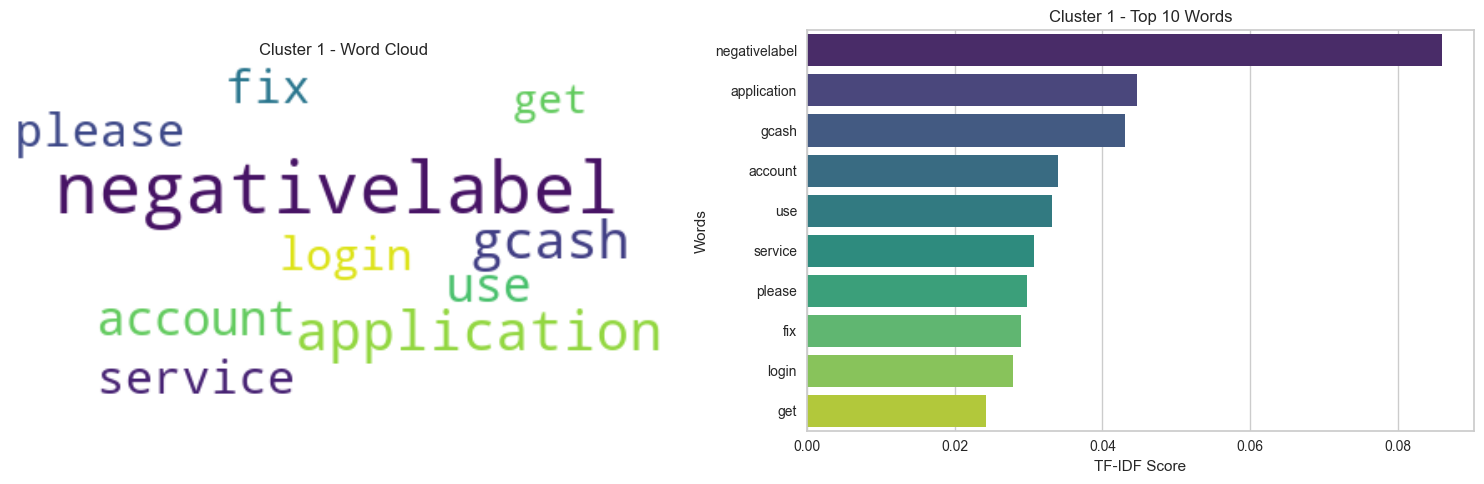

C:\Users\Neil\AppData\Local\Temp\ipykernel_17544\190333237.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=scores, y=words, ax=axes[1], palette="viridis")


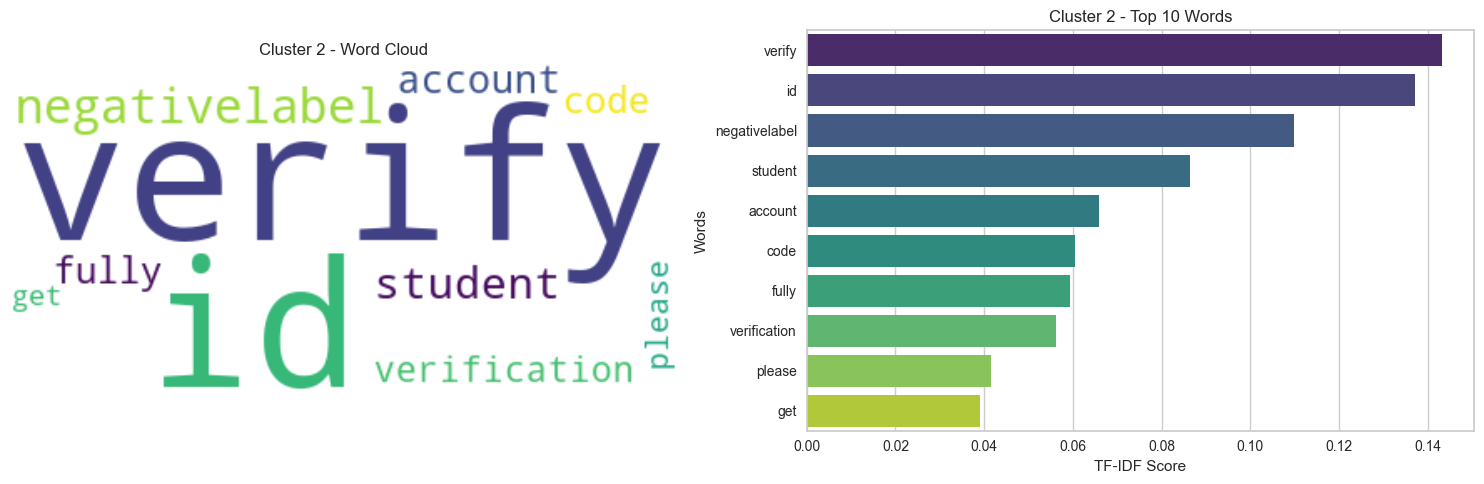

C:\Users\Neil\AppData\Local\Temp\ipykernel_17544\190333237.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=scores, y=words, ax=axes[1], palette="viridis")


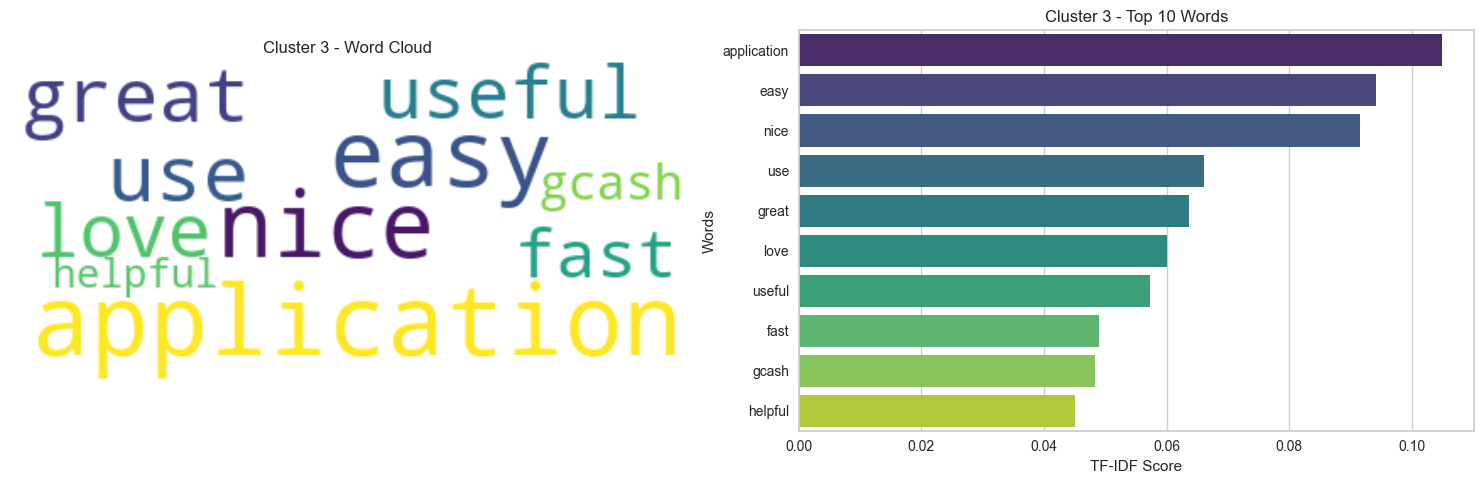

C:\Users\Neil\AppData\Local\Temp\ipykernel_17544\190333237.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=scores, y=words, ax=axes[1], palette="viridis")


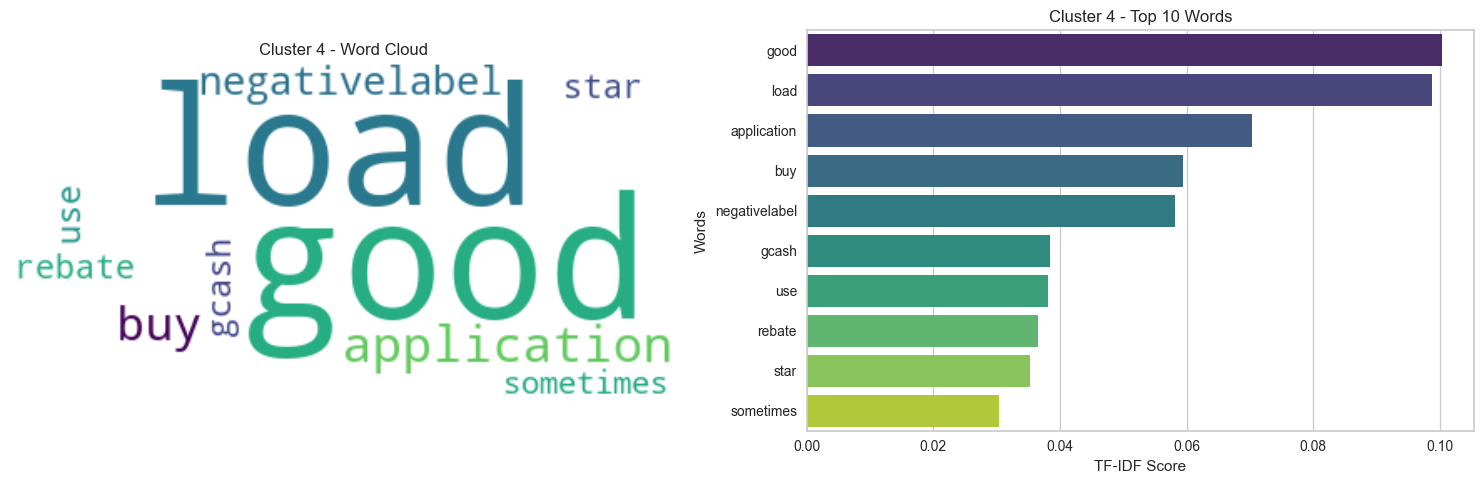

C:\Users\Neil\AppData\Local\Temp\ipykernel_17544\190333237.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=scores, y=words, ax=axes[1], palette="viridis")


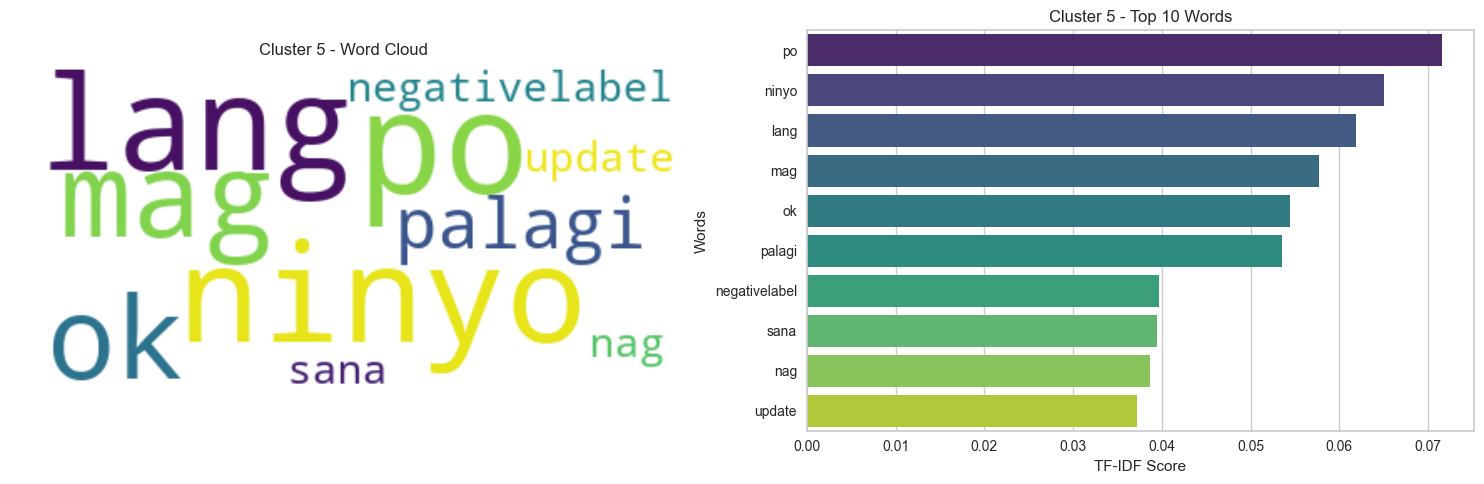

C:\Users\Neil\AppData\Local\Temp\ipykernel_17544\190333237.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=scores, y=words, ax=axes[1], palette="viridis")


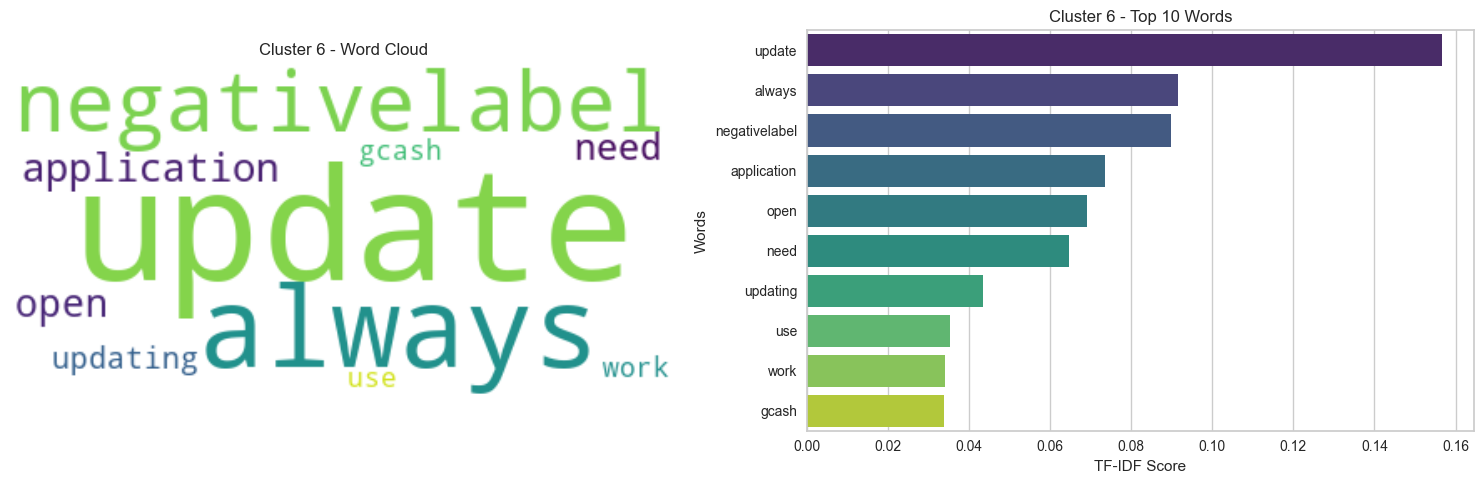

In [166]:
def get_frequencies(cluster_index, top_n=10):
    """Get top words and their scores for a cluster."""
    if cluster_index >= num_clusters:
        return None, None

    term_frequencies = approx_tfidf[cluster_index]
    
    # Get top words
    sorted_indices = np.argsort(term_frequencies)[::-1][:top_n]
    words = [terms[i] for i in sorted_indices]
    scores = [term_frequencies[i] for i in sorted_indices]
    
    frequencies = {terms[i]: term_frequencies[i] for i in sorted_indices}
    
    return words, scores, frequencies

def plot_combined(cluster_index, top_n=10):
    """Plot word cloud & bar chart side by side."""
    words, scores, frequencies = get_frequencies(cluster_index, top_n)
    if words is None:
        return

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Word Cloud
    wc = WordCloud(background_color="white", max_words=top_n)
    wc.generate_from_frequencies(frequencies)
    axes[0].imshow(wc, interpolation="bilinear")
    axes[0].axis("off")
    axes[0].set_title(f"Cluster {cluster_index} - Word Cloud")

    # Bar Chart
    sns.barplot(x=scores, y=words, ax=axes[1], palette="viridis")
    axes[1].set_xlabel("TF-IDF Score")
    axes[1].set_ylabel("Words")
    axes[1].set_title(f"Cluster {cluster_index} - Top {top_n} Words")

    plt.tight_layout()
    plt.show()

# Generate plots for each cluster
for i in range(num_clusters):
    plot_combined(i, top_n=10)

# # Extract feature names (words)
# terms = vectorizer.get_feature_names_out()

# # Ensure df_tfidf is a DataFrame and matches df's shape
# df_tfidf = pd.DataFrame(X, columns=terms)

# # Merge cluster labels from df
# df_tfidf['cluster'] = df['cluster'].values

# # Compute total TF-IDF scores per word in each cluster
# cluster_word_counts = df_tfidf.groupby('cluster').sum()

# def get_frequencies(cluster_index, top_n=10):
#     """Get top words and their scores + total word counts for a cluster."""
#     if cluster_index >= num_clusters:
#         return None, None, None, None

#     # Get term frequencies (TF-IDF sum per word in the cluster)
#     term_frequencies = cluster_word_counts.iloc[cluster_index]

#     # Get top N words based on TF-IDF score
#     sorted_indices = term_frequencies.argsort()[::-1][:top_n]
#     words = [terms[i] for i in sorted_indices]
#     scores = [term_frequencies.iloc[i] for i in sorted_indices]

#     # Get actual word occurrences (raw count)
#     counts = df_tfidf[words].sum().values  # Get word counts for selected words

#     # Dictionary for word cloud
#     frequencies = {words[i]: scores[i] for i in range(len(words))}

#     return words, scores, frequencies, counts

# def plot_combined(cluster_index, top_n=10):
#     """Plot word cloud & bar chart with word counts side by side."""
#     words, scores, frequencies, counts = get_frequencies(cluster_index, top_n)
#     if words is None:
#         return

#     fig, axes = plt.subplots(1, 2, figsize=(15, 5))

#     # Word Cloud
#     wc = WordCloud(background_color="white", max_words=top_n)
#     wc.generate_from_frequencies(frequencies)
#     axes[0].imshow(wc, interpolation="bilinear")
#     axes[0].axis("off")
#     axes[0].set_title(f"Cluster {cluster_index} - Word Cloud")

#     # Bar Chart
#     ax = sns.barplot(x=scores, y=words, ax=axes[1], palette="viridis")

#     # Add text labels for total word counts
#     for i, count in enumerate(counts):
#         ax.text(scores[i], i, f" {int(count)}", va='center', fontsize=10, color='black')

#     axes[1].set_xlabel("TF-IDF Score")
#     axes[1].set_ylabel("Words")
#     axes[1].set_title(f"Cluster {cluster_index} - Top {top_n} Words")

#     plt.tight_layout()
#     plt.show()

# # Generate plots for each cluster
# for i in range(num_clusters):
#     plot_combined(i, top_n=10)

In [167]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.cluster import KMeans, DBSCAN

# Compute metrics for K-Means
print("K-Means Metrics:")
print("Silhouette Score:", silhouette_score(X_umap, kmeans_labels, metric='euclidean'))
print("Davies-Bouldin Index:", davies_bouldin_score(X_umap, kmeans_labels))
print("Calinski-Harabasz Index:", calinski_harabasz_score(X_umap, kmeans_labels))

K-Means Metrics:
Silhouette Score: 0.38290596
Davies-Bouldin Index: 0.7796908593698301
Calinski-Harabasz Index: 30289.512


In [168]:
# import umap.umap_ as umap

# # Reduce to 2D using UMAP
# umap_model = umap.UMAP(n_components=2, random_state=42)
# X_2d = umap_model.fit_transform(X_svd)

# # Plot clusters
# plt.figure(figsize=(10, 6))
# sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=kmeans.labels_, palette='tab10', alpha=0.7)
# plt.xlabel("UMAP Component 1")
# plt.ylabel("UMAP Component 2")
# plt.title("K-Means Clustering Visualization with UMAP")
# plt.legend(title="Cluster")
# plt.show()

In [169]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Convert to DataFrame with only first two components
# df_pca = pd.DataFrame(X_svd[:, :2], columns=['PC1', 'PC2'])
# df_pca['cluster'] = df['cluster']  # Assign KMeans cluster labels

# # Plot using Seaborn
# plt.figure(figsize=(10, 6))
# sns.scatterplot(x='PC1', y='PC2', hue='cluster', palette='viridis', data=df_pca, alpha=0.7)
# plt.title("PCA Visualization of KMeans Clusters")
# plt.xlabel("Principal Component 1")
# plt.ylabel("Principal Component 2")
# plt.legend(title='Cluster')
# plt.show()


In [170]:
# plt.figure(figsize=(8,6))
# plt.scatter(X_svd[:,0], X_svd[:,1], c=df['cluster'], cmap='viridis', alpha=0.5)
# plt.colorbar(label="Cluster")
# plt.xlabel("PCA Component 1")
# plt.ylabel("PCA Component 2")
# plt.title("Clusters Visualized using PCA")
# plt.show()